In [ ]:
import netket as nk
import numpy as np

import netket.experimental as nkx

# 1D chain
L =4

g = nk.graph.Hypercube(length=L, n_dim=1, pbc=True)

# Hilbert space of spins on the graph
hi = nk.hilbert.Spin(s=1 / 2, N=g.n_nodes, inverted_ordering=True)

# Ising spin hamiltonian
ha = nk.operator.Ising(hilbert=hi, graph=g, h=1.0)

# RBM Spin Machine
ma = nk.models.RBM(alpha=1, use_visible_bias=True, param_dtype=complex)

# Metropolis Local Sampling
sa = nk.sampler.MetropolisHamiltonian(hi, ha, n_chains=16)

# Variational state
vs = nk.vqs.MCState(sa, ma, n_samples=1024, n_discard_per_chain=16)

# Optimizer
op = nk.optimizer.Sgd(0.01)
sr = nk.optimizer.SR(diag_shift=1e-4)

# Variational monte carlo driver
gs = nk.driver.VMC(ha, op, variational_state=vs)

# Create observable
Sx = sum([nk.operator.spin.sigmax(hi, i) for i in range(L)])

# Run the optimization for 300 iterations to determine the ground state, used as
# initial state of the time-evolution
gs.run(n_iter=3, out="example_ising1d_GS_4site", obs={"Sx": Sx})

# Create ODE solver for time propagation
solver = nkx.dynamics.RK23(dt=0.01, adaptive=True, rtol=1e-3, atol=1e-3)
print(solver)

# Quenched hamiltonian: this has a different transverse field than `ha`
ha1 = nk.operator.Ising(hilbert=hi, graph=g, h=0.5)
te = nkx.TDVP(
    ha1,
    variational_state=vs,
    ode_solver=solver,
    t0=0.0,
    qgt=nk.optimizer.qgt.QGTJacobianDense(holomorphic=True, diag_shift=1e-4),
    error_norm="qgt",
)

log = nk.logging.JsonLog("example_ising1d_TE")

# perform the time-evolution saving the observable Sx at every `tstop` time
te.run(
    T=1.0,
    out=log,
    show_progress=True,
    obs={"Sx": Sx},
    tstops=np.linspace(0.0, 1.0, 101, endpoint=True),
)

100%|██████████| 3/3 [00:00<00:00, 17.10it/s, Energy=-3.998-0.000j ± 0.062 [σ²=4.064, R̂=1.0027]]


RKExplicitSolver(tableau=RK23, dt=0.01, adaptive=True, integrator_parameters=IntegratorParameters(dt=0.01, atol=0.001, rtol=0.001, dt_limits=(None, 0.1)))


100%|██████████| 1.00/1.00 [00:49<00:00, 49.7s/it, n=109, Generator=-1.646+0.011j ± 0.092 [σ²=4.851, R̂=1.1312]]


(JsonLog('example_ising1d_TE', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.07775306701660156
   	Params: 0.0380251407623291,)

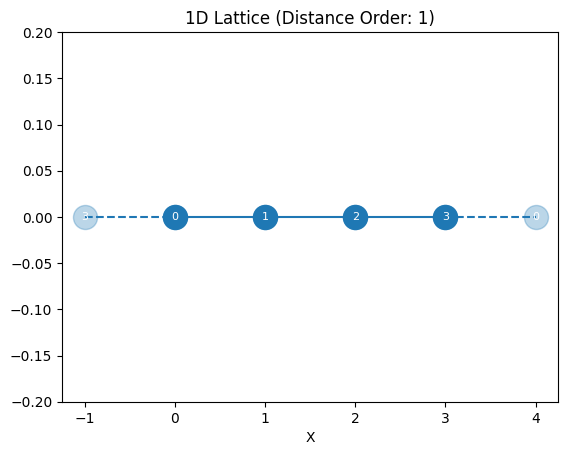

<Axes: title={'center': '1D Lattice (Distance Order: 1)'}, xlabel='X'>

In [22]:
g.draw()

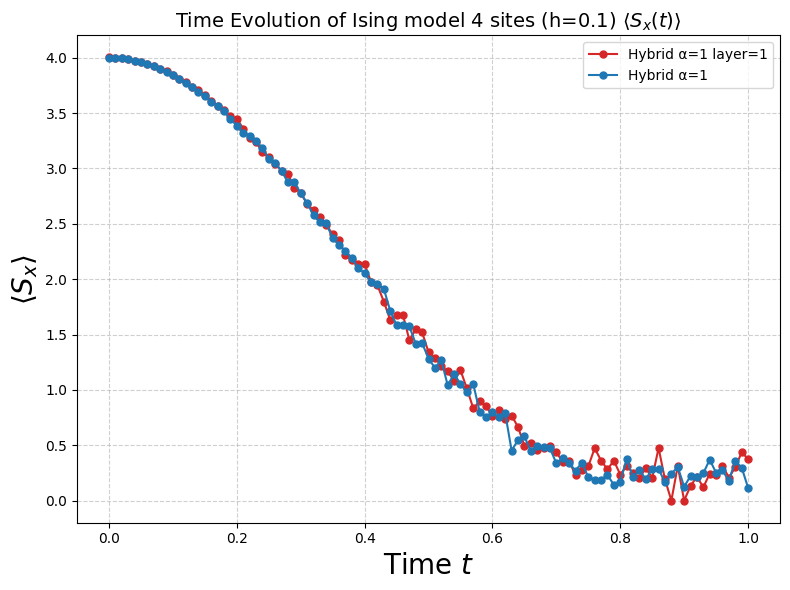

In [21]:
import json
import matplotlib.pyplot as plt

# 加载日志文件（注意：NetKet 的 JsonLog 默认是单行 JSON）
log_file = 'example_ising1d_TE.log'

with open(log_file, 'r') as f:
    data = json.load(f)  # 使用 json.load，不是 json.loads 每一行！
times = data['Sx']['iters']
s_x_real = data['Sx']['Mean']['real']
# s_x_real2 = data2['Sx']['Mean']['real']
# 如果想画复数模长，可用：np.abs(np.array(s_x_real) + 1j * np.array(data['Sx']['Mean']['imag']))

# 绘图
plt.figure(figsize=(8, 6))
plt.plot(times, s_x_real, 'o-', color='tab:red', markersize=5,label='Hybrid α=1 layer=1')
plt.plot(times, s_x_real2, 'o-', color='tab:blue', markersize=5,label='Hybrid α=1')
plt.title(r'Time Evolution of Ising model 4 sites (h=0.1) $\langle S_x(t) \rangle$', fontsize=14)
plt.xlabel('Time $t$', fontsize=20)
plt.ylabel(r'$\langle S_x \rangle$', fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend()
plt.show()

In [5]:
# Copyright 2021 The NetKet Authors - All rights reserved.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#    http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

import netket as nk
import numpy as np

import netket.experimental as nkx

# 1D chain
L =4

g = nk.graph.Hypercube(length=L, n_dim=1, pbc=True)

# Hilbert space of spins on the graph
hi = nk.hilbert.Spin(s=1 / 2, N=g.n_nodes, inverted_ordering=True)

# Ising spin hamiltonian
ha = nk.operator.Ising(hilbert=hi, graph=g, h=1.0)

# RBM Spin Machine
ma = nk.models.RBMModPhase(alpha=2, param_dtype=complex)

# Metropolis Local Sampling
sa = nk.sampler.MetropolisHamiltonian(hi, ha, n_chains=16)

# Variational state
vs = nk.vqs.MCState(sa, ma, n_samples=1024, n_discard_per_chain=16)

# Optimizer
op = nk.optimizer.Sgd(0.01)
sr = nk.optimizer.SR(diag_shift=1e-4)

# Variational monte carlo driver
gs = nk.driver.VMC(ha, op, variational_state=vs)

# Create observable
Sx = sum([nk.operator.spin.sigmax(hi, i) for i in range(L)])

# Run the optimization for 300 iterations to determine the ground state, used as
# initial state of the time-evolution
gs.run(n_iter=3, out="example_ising1d_GS", obs={"Sx": Sx})

# Create ODE solver for time propagation
solver = nkx.dynamics.RK23(dt=0.01, adaptive=True, rtol=1e-3, atol=1e-3)
print(solver)

# Quenched hamiltonian: this has a different transverse field than `ha`
ha1 = nk.operator.Ising(hilbert=hi, graph=g, h=0.5)
te = nkx.TDVP(
    ha1,
    variational_state=vs,
    ode_solver=solver,
    t0=0.0,
    qgt=nk.optimizer.qgt.QGTJacobianDense(holomorphic=True, diag_shift=1e-4),
    error_norm="qgt",
)

log = nk.logging.JsonLog("example_ising1d_TE_mod")

# perform the time-evolution saving the observable Sx at every `tstop` time
te.run(
    T=1.0,
    out=log,
    show_progress=True,
    obs={"Sx": Sx},
    tstops=np.linspace(0.0, 1.0, 101, endpoint=True),
)

100%|██████████| 3/3 [00:00<00:00, 23.61it/s, Energy=-4.004-0.000j ± 0.062 [σ²=3.950, R̂=1.0052]]


RKExplicitSolver(tableau=RK23, dt=0.01, adaptive=True, integrator_parameters=IntegratorParameters(dt=0.01, atol=0.001, rtol=0.001, dt_limits=(None, 0.1)))


100%|██████████| 1.00/1.00 [00:32<00:00, 32.0s/it, n=114, Generator=-2.165+0.015j ± 0.084 [σ²=4.197, R̂=1.0924]] 


(JsonLog('example_ising1d_TE_mod', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.0482785701751709
   	Params: 0.028725147247314453,)

In [3]:
import json

# 加载日志文件
log_file = 'example_ising1d_TE.log'

with open(log_file, 'r') as f:
    # 打印前5条记录进行检查
    for i, line in enumerate(f):
        if i >= 5: break
        print(json.loads(line))

{'Sx': {'iters': [0.0, 0.01, 0.020000000000000004, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35000000000000003, 0.36, 0.37, 0.38, 0.39, 0.4, 0.41000000000000003, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47000000000000003, 0.48, 0.49, 0.5, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.5700000000000001, 0.58, 0.59, 0.6, 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.6900000000000001, 0.7000000000000001, 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8, 0.81, 0.8199972049800627, 0.8300000000000001, 0.84], 'Mean': {'real': [9.99872132439545, 9.9891277640843, 9.98248717697136, 9.959420489747247, 9.935271650312409, 9.895615096813021, 9.853440723678434, 9.801708248796208, 9.741170041316138, 9.678514813503712, 9.597148590465947, 9.520076895321791, 9.43798763002804, 9.335130605573607, 9.246079578594802, 9.136986770606358, 9.024919938817336, 8.8861215977

In [ ]:
log_file2 = 'example_ising1d_TE_mod.log'

with open(log_file2, 'r') as f:
    # 打印前5条记录进行检查
    for i, line in enumerate(f):
        if i >= 5: break
        print(json.loads(line))

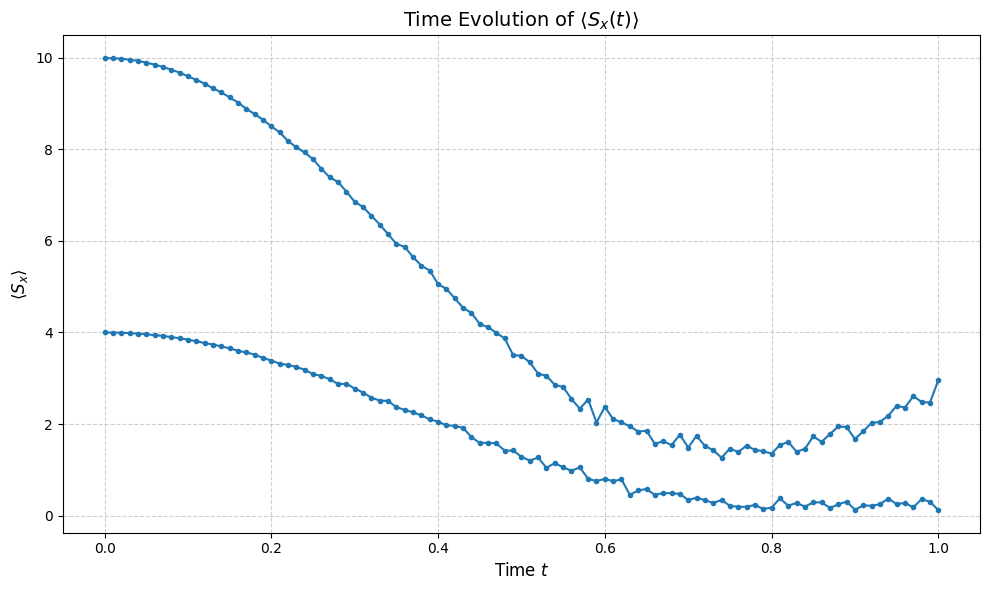

In [6]:
import json
import matplotlib.pyplot as plt

# 加载日志文件（注意：NetKet 的 JsonLog 默认是单行 JSON）
log_file = 'example_ising1d_TE.log'

with open(log_file, 'r') as f:
    data = json.load(f)  # 使用 json.load，不是 json.loads 每一行！

with open('example_ising1d_TE_mod.log', 'r') as f:
    data2 = json.load(f)  # 使用 json.load，不是 json.loads 每一行！
# 提取时间与 <Sx> 实部（虚部通常接近0，可忽略）
times = data['Sx']['iters']
s_x_real = data['Sx']['Mean']['real']
s_x_real2 = data2['Sx']['Mean']['real']
# 如果想画复数模长，可用：np.abs(np.array(s_x_real) + 1j * np.array(data['Sx']['Mean']['imag']))

# 绘图
plt.figure(figsize=(10, 6))
plt.plot(times, s_x_real, 'o-', color='tab:blue', markersize=3)
plt.plot(times, s_x_real2, 'o-', color='tab:blue', markersize=3)
plt.title(r'Time Evolution of $\langle S_x(t) \rangle$', fontsize=14)
plt.xlabel('Time $t$', fontsize=12)
plt.ylabel(r'$\langle S_x \rangle$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()